# Hustleton City Traffic Problem: Transportation Analysis

This notebook prepares presentation-ready visuals for a consulting case study on shifting transportation mode share in Hustleton City.

## 1. Setup & Data Loading

The two datasets are created directly from the case prompt to keep the analysis reproducible and portfolio-friendly.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter


# Notebook-wide plotting defaults for clean, corporate visuals.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "axes.titlesize": 16,
        "font.family": "DejaVu Sans",
        "legend.frameon": False,
    }
)

# Centralized output directory for README-ready chart exports.
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Dataset 1: Yearly transportation mode share, expressed as percentages.
mode_share_data = {
    "Year": [2021, 2022, 2023],
    "Public Transport": [55, 35, 20],
    "Private Taxis": [15, 20, 25],
    "Personal Vehicles": [30, 45, 55],
}

mode_share_df = pd.DataFrame(mode_share_data)

# Long format keeps visualization logic clean and extensible.
mode_share_long_df = mode_share_df.melt(
    id_vars="Year",
    var_name="Transportation Mode",
    value_name="Mode Share",
)

# Dataset 2: Transportation modes breakdown.
modes_breakdown_data = [
    {
        "Mode": "Buses",
        "Coverage": "Key districts only",
        "Cost (USD)": 2,
        "Customer Feedback": "Cheapest but complicated stops",
    },
    {
        "Mode": "The Tube",
        "Coverage": "Central city only",
        "Cost (USD)": 7,
        "Customer Feedback": "Reliable but crowded in rush hour",
    },
    {
        "Mode": "Over-ground rail",
        "Coverage": "Outside city center",
        "Cost (USD)": 7,
        "Customer Feedback": "Accessible but lots of stops",
    },
    {
        "Mode": "Taxi",
        "Coverage": "Full city",
        "Cost (USD)": 25,
        "Customer Feedback": "Very expensive",
    },
]

modes_breakdown_df = pd.DataFrame(modes_breakdown_data)

display(mode_share_df)
display(modes_breakdown_df)

,Year,Public Transport,Private Taxis,Personal Vehicles
0,2021,55,15,30
1,2022,35,20,45
2,2023,20,25,55


,Mode,Coverage,Cost (USD),Customer Feedback
0,Buses,Key districts only,2,Cheapest but complicated stops
1,The Tube,Central city only,7,Reliable but crowded in rush hour
2,Over-ground rail,Outside city center,7,Accessible but lots of stops
3,Taxi,Full city,25,Very expensive


## 2. Visualization 1: The Trend

The chart highlights a 35 percentage-point decline in public transport share from 2021 to 2023, alongside a 25 percentage-point increase in personal vehicle share.

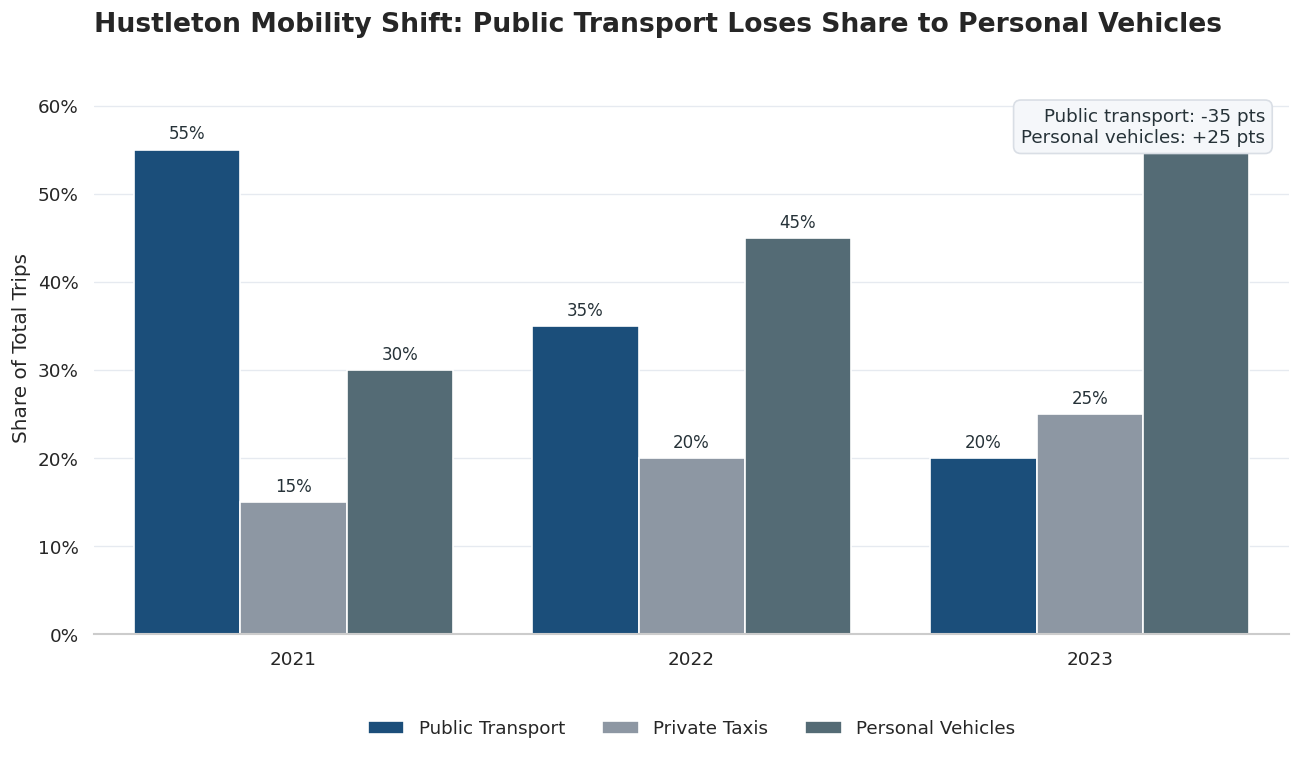

In [2]:
# Corporate palette: primary blue, slate gray, and muted steel.
mode_palette = {
    "Public Transport": "#0B4F8A",
    "Private Taxis": "#8A97A6",
    "Personal Vehicles": "#4F6D7A",
}

fig, ax = plt.subplots(figsize=(11, 6.5))

sns.barplot(
    data=mode_share_long_df,
    x="Year",
    y="Mode Share",
    hue="Transportation Mode",
    palette=mode_palette,
    ax=ax,
)

# Add bar labels to make the chart presentation-ready without extra narration.
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{value.get_height():.0f}%" for value in container],
        padding=4,
        fontsize=10,
        color="#263238",
    )

ax.set_title(
    "Hustleton Mobility Shift: Public Transport Loses Share to Personal Vehicles",
    loc="left",
    pad=18,
)
ax.set_xlabel("")
ax.set_ylabel("Share of Total Trips")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_ylim(0, 65)

# Directly call out the strategic insight: public transport declined 35 percentage points.
public_transport_decline = (
    mode_share_df.loc[mode_share_df["Year"] == 2023, "Public Transport"].iloc[0]
    - mode_share_df.loc[mode_share_df["Year"] == 2021, "Public Transport"].iloc[0]
)
personal_vehicle_growth = (
    mode_share_df.loc[mode_share_df["Year"] == 2023, "Personal Vehicles"].iloc[0]
    - mode_share_df.loc[mode_share_df["Year"] == 2021, "Personal Vehicles"].iloc[0]
)

insight_text = (
    f"Public transport: {public_transport_decline:+.0f} pts\n"
    f"Personal vehicles: {personal_vehicle_growth:+.0f} pts"
)
ax.text(
    0.98,
    0.92,
    insight_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    color="#263238",
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "#F5F7FA",
        "edgecolor": "#D9DEE5",
    },
)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=11)
sns.despine(left=True, bottom=False)
ax.grid(axis="y", color="#E6EAF0", linewidth=0.8)
ax.grid(axis="x", visible=False)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "hustleton_transport_mode_share_trend.png", bbox_inches="tight")
plt.show()

## 3. Data Formatting: Transportation Modes Breakdown

The formatted table makes coverage and cost tradeoffs easy to scan in a notebook or exported portfolio asset.

In [3]:
def highlight_cost_tier(cost_series: pd.Series) -> list[str]:
    """Apply MECE cost-tier styling based on relative affordability."""
    styles = []

    for raw_cost in cost_series:
        cost = float(str(raw_cost).replace("$", "").replace(",", ""))
        if cost <= 2:
            styles.append("background-color: #EAF4EA; color: #1B5E20; font-weight: 600")
        elif cost <= 7:
            styles.append("background-color: #EEF4FB; color: #0B4F8A; font-weight: 600")
        else:
            styles.append("background-color: #FBEAEA; color: #8A1F1F; font-weight: 600")

    return styles


formatted_modes_df = modes_breakdown_df.copy()
formatted_modes_df["Cost"] = formatted_modes_df["Cost (USD)"].map("${:,.0f}".format)
formatted_modes_df = formatted_modes_df[
    ["Mode", "Coverage", "Cost", "Customer Feedback", "Cost (USD)"]
]

modes_breakdown_table = (
    formatted_modes_df.style
    .hide(axis="index")
    .hide(axis="columns", subset=["Cost (USD)"])
    .apply(highlight_cost_tier, subset=["Cost"])
    .set_caption("Transportation Modes Breakdown: Cost vs. Coverage Tradeoffs")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "700"),
                    ("text-align", "left"),
                    ("color", "#263238"),
                    ("padding-bottom", "10px"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#263238"),
                    ("color", "white"),
                    ("font-weight", "700"),
                    ("text-align", "left"),
                    ("padding", "10px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("border-bottom", "1px solid #E6EAF0"),
                    ("padding", "10px"),
                    ("text-align", "left"),
                    ("vertical-align", "top"),
                ],
            },
            {
                "selector": "tbody tr:hover",
                "props": [("background-color", "#F5F7FA")],
            },
        ]
    )
    .set_properties(
        subset=["Mode"],
        **{"font-weight": "700", "color": "#263238"},
    )
    .set_properties(
        subset=["Coverage", "Customer Feedback"],
        **{"color": "#37474F"},
    )
)

modes_breakdown_table

Mode,Coverage,Cost,Customer Feedback
Buses,Key districts only,$2,Cheapest but complicated stops
The Tube,Central city only,$7,Reliable but crowded in rush hour
Over-ground rail,Outside city center,$7,Accessible but lots of stops
Taxi,Full city,$25,Very expensive
